In [1]:
### This script is used to analyze the 2p data and corresponding treadmill behavior data
### 1. Load the 2p data and treadmill behavior data
### 2. Align the 2p data and treadmill behavior data
### 3a. Smooth the deconvolved traces using a 250 ms Gaussian window
### 3b. Remove inactive data points
### 4. Spatial discretization (divide the VR corridor into ~110 bins, each representing 1cm and assign each data point to its corresponding spatial bin)
### 5. Test for reliability for individual cells (calculate Pearson CC or cohen’s D)
### 6. Plotting activity of all responsive cells (cross validation – split trials in half)
### 7. Population vector cross-correlation 

In [2]:
%cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


**1. Load the 2p data and treadmill behavior data**

In [3]:
import os
import re
import datetime
import numpy as np
from helper import TwoP, read_xml, time2float
import matplotlib.pyplot as plt

# File path to VRlog.txt and 2p data
filepath = r'D:\V1_SpatialModulation\2p\250206_JSY_JSY038_SpatialModulation\TSeries-02062025-1350-001'
VRfilepath = r"D:\V1_SpatialModulation\V1_SpatialMod_VRLog"
twoP_filename = "TSeries-02062025-1350-001"
VRlog_filename = "VRlog_JSY038_02062025_01-56-15.txt"
VRlog_path = os.path.join(VRfilepath, VRlog_filename)

# Extract animal ID and date from the VR_log_filename
match = re.match(r"VRlog_(JSY\d+)_(\d{8})_\d{2}-\d{2}-\d{2}\.txt", VRlog_filename)
if match:
    animal_id = match.group(1)
    date = match.group(2)
else:
    print("Filename format does not match the expected pattern.")

# Initialize dictionaries to store raw data
twoP_data = {}
VR_data = {}

# Load twoP data
raw_twop_data = TwoP(filepath, twoP_filename)

raw_twop_data.find_files()
twop_dict = raw_twop_data.calc_dFF()

twoP_data['sps'] = twop_dict['spikes_per_sec'].copy()
twoP_data['s2p_spks'] = twop_dict['s2p_spks'].copy()
twoP_data['dFF'] = twop_dict['norm_dFF'].copy()

numFrames = np.size(twoP_data['sps'], 1)

xml_path = os.path.join(filepath, f"{twoP_filename}.xml")
xml_dict = read_xml(xml_path)
t0 = xml_dict["t0"]
abs_time = xml_dict["abs_time"]
rel_time = xml_dict["rel_time"]
framerate = 1/rel_time[1]
print(framerate)

twopT = np.zeros(np.size(abs_time, 0) - 1, dtype=datetime.datetime)
for rep, t in enumerate(abs_time[:-1]):
    twopT[rep] = t0 + datetime.timedelta(seconds=t)

twopT_float = time2float(twopT)
twoP_data['AbsoluteT'] = twopT

# # print the data type of twoP_data['twopT'[0]]
# print(type(twoP_data['AbsoluteT'][0]))


# Load VRlog
rawVR_data = []
with open(VRlog_path, "r") as file:
    lines = file.readlines()
    for line in lines[3:]:
        rawVR_data.append(line.strip().split("\t"))
        
# Extract VR data
VR_data['absoluteT'] = np.array([line[0] for line in rawVR_data])
VR_data['elapsedT'] = np.array([float(line[1]) for line in rawVR_data])
VR_data['event'] = np.array([line[2] for line in rawVR_data])
VR_data['location'] = np.array([float(line[3]) for line in rawVR_data])

# Find the index of the first 's' in VR_data['event']
start_index = np.where(VR_data['event'] == 's')[0][0]

# Erase all elements before the start_index in all VR_data
for key in VR_data.keys():
    VR_data[key] = VR_data[key][start_index:]

# # for every element of VR_data, print first value
# for key in VR_data:
#     print(VR_data[key][0])

print("first time value of VR is", VR_data['absoluteT'][0])
print("first time value of 2p is", twoP_data['AbsoluteT'][0] )

c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\oasis\functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\oasis\functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


10.02190708713992
first time value of VR is 01.56.16.128350
first time value of 2p is 2025-02-06 13:56:17.280286


**2. Align the 2p data and treadmill behavior data**

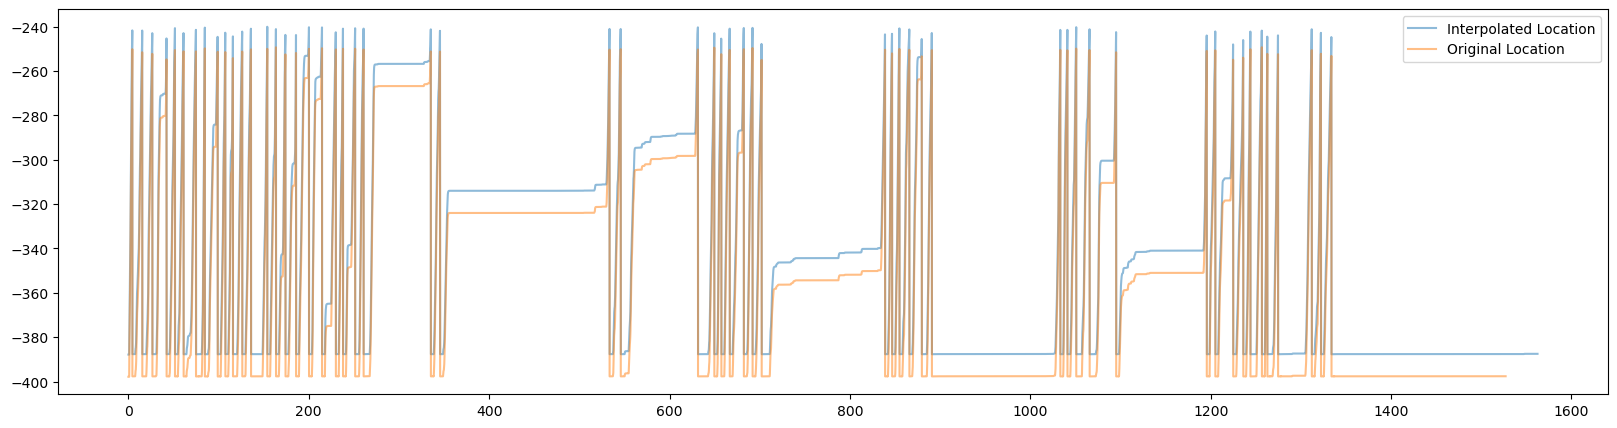

In [4]:
# Define absolute_t0 as the third element of VR_data['absoluteT'] -- with "s" for event type, which is the timestamp for 2p input trigger
VR_absolute_t = np.array([datetime.datetime.strptime(t, '%H.%M.%S.%f') for t in VR_data['absoluteT'][0:]])

# Calculate relative_t (time elapsed from absolute_t0)
VR_relative_t = np.array([(t - VR_absolute_t[0]).total_seconds() for t in VR_absolute_t])

# Add twoP_data['AbsoluteT'][0] to each timedelta object to get vrT
VR_relative_t_timedelta = np.array([datetime.timedelta(seconds=t) for t in VR_relative_t])
Aligned_Abs_vrT = twoP_data['AbsoluteT'][0] + VR_relative_t_timedelta

# Find the closest value in Aligned_Abs_vrT that is greater than twoP_data['AbsoluteT'][-1]
closest_value = Aligned_Abs_vrT[Aligned_Abs_vrT > twoP_data['AbsoluteT'][-1]][0]
closest_index = np.where(Aligned_Abs_vrT == closest_value)[0][0]

# print(closest_value)
# print(closest_index)

new_VR_data = {}
new_VR_data['AbsoluteT'] = np.array(Aligned_Abs_vrT)[:closest_index]
new_VR_data['RelativeT'] = VR_relative_t[:closest_index]
new_VR_data['event'] = VR_data['event'][:closest_index]
new_VR_data['location'] = VR_data['location'][:closest_index]

# Calculate relative time points for VR_data and twoP_data
twop_relativeT = twoP_data['AbsoluteT'] - twoP_data['AbsoluteT'][0]

# Convert to seconds
twop_relativeT = np.array([t.total_seconds() for t in twop_relativeT])
twoP_data['RelativeT'] = twop_relativeT

# print("start of 2p is", twoP_data['RelativeT'][0])
# print("start of VR is", new_VR_data['RelativeT'][0])

# print("end of 2p is", twoP_data['RelativeT'][-1])
# print("end of VR is", new_VR_data['RelativeT'][-1])

# Interpolate the location at twoP_data['RelativeT'] from new_VR_data['location'] at new_VR_data['RelativeT']
interpolated_location = np.interp(twoP_data['RelativeT'], new_VR_data['RelativeT'], new_VR_data['location'])
new_VR_data['interp_location'] = interpolated_location

# for all other keys in new_VR_data, cut off the last few elements to match the length of interpolated_location
for key in new_VR_data.keys():
    new_VR_data[key] = new_VR_data[key][:len(interpolated_location)]
    

# # Now interpolated_location contains the interpolated location values at twop_relativeT
# print(new_VR_data['location'].shape)
# print(twoP_data['RelativeT'].shape)
# print(interpolated_location.shape)

# Plot the interpolated location
plt.figure(figsize=(20, 5))
plt.plot(twoP_data['RelativeT'], new_VR_data['interp_location']+10, label="Interpolated Location", alpha=0.5)
plt.plot(new_VR_data['RelativeT'], new_VR_data['location'], label="Original Location", alpha=0.5)
plt.legend()
plt.show()

# print(interpolated_location[0:10])
# print(aligned_VR_data['aligned_location'][0:10])

# plt.figure(figsize=(20, 5))
# plt.plot(twoP_data['RelativeT'], twoP_data['dFF'][10, :])
# plt.show()

# plt.figure(figsize=(20, 5))
# plt.plot(twoP_data['RelativeT'], twoP_data['sps'][10, :])
# plt.show()

**3a. Smooth the deconvolved traces using a 250 ms Gaussian window**

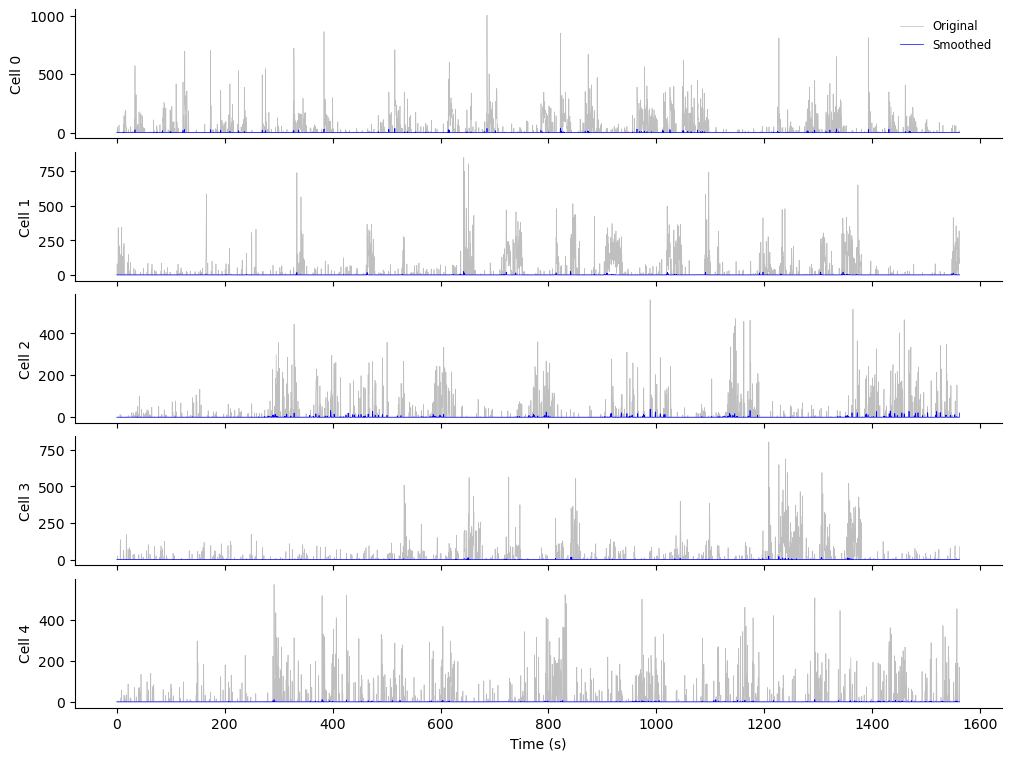

In [5]:
import numpy as np
from helper import SpikeSmoothing

# smoothed = SpikeSmoothing.smooth_spikes(twoP_data['sps'], framerate, window_ms=500)
smoothed = SpikeSmoothing.smooth_spikes(twoP_data['sps'], framerate, window_ms=800)
twoP_data['smoothed_spks'] = smoothed
SpikeSmoothing.plot_comparison(twoP_data['s2p_spks'], smoothed, framerate)

**3b. Remove inactive data points**

Location range: -397.81 to -250.10
Using high threshold: -284.54 (at 90th percentile)
Using low threshold: -397.60 (at 10th percentile)
Removed 1 incomplete laps
Found 56 laps
Lap lengths: [  45  110  112  158   93   96  138   98  143   85   84  104   97  181
   97  105  118  143  145  154   79  135   94  747  103 1883  125  858
  181   79   93  156   97  102 1371   78   82  110  138  112 1427   79
   98  149  295 1007   95  198  112   80  127   61  119  375  102  116]


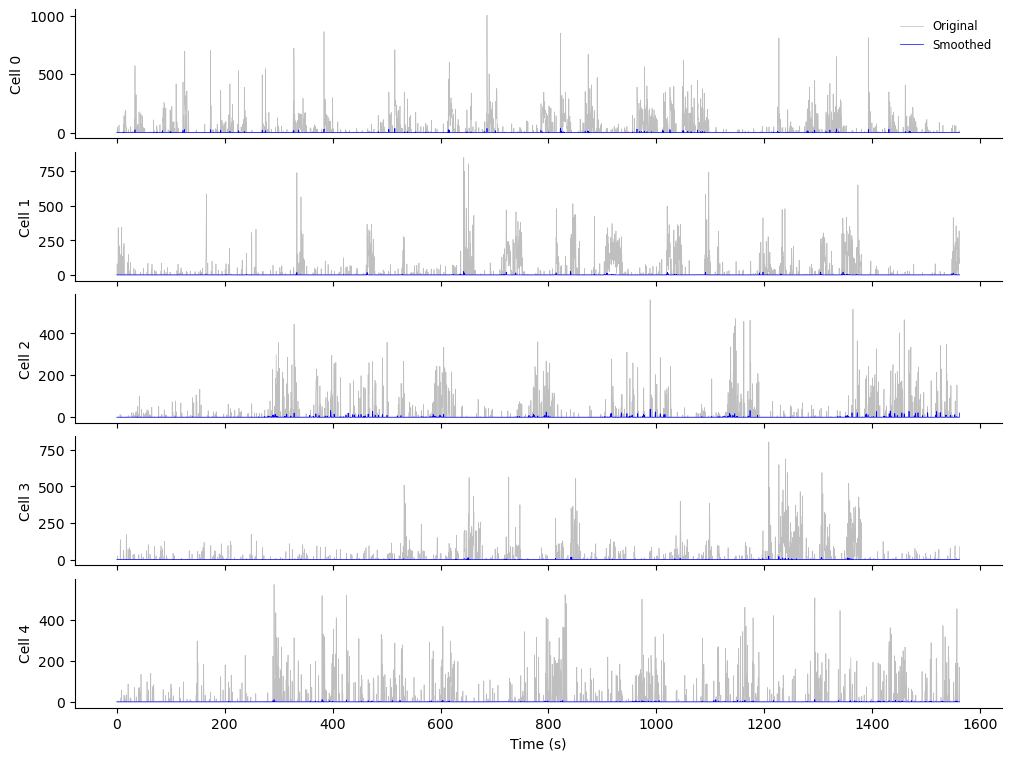

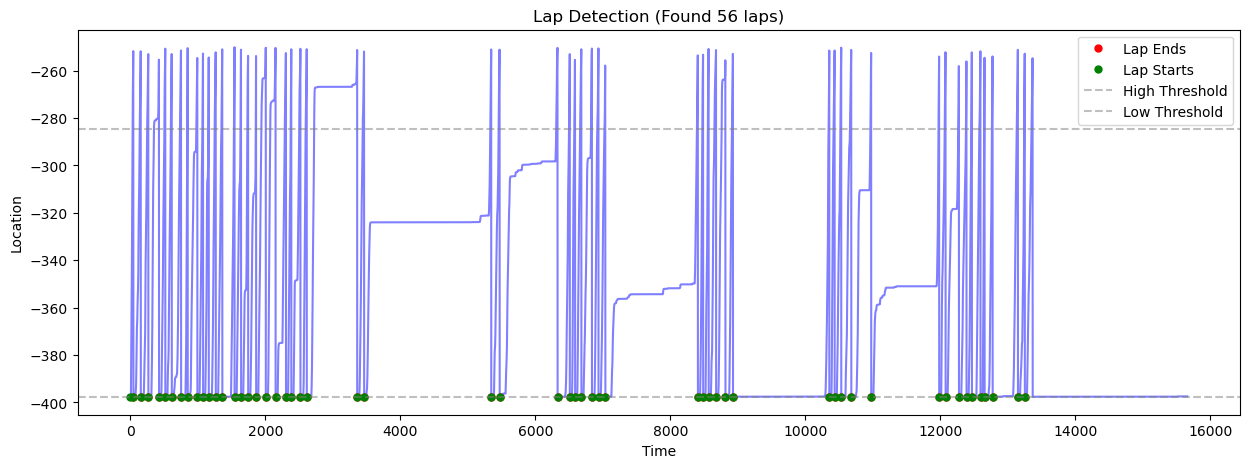

number of detected laps: 56

Filtering trials by duration:

Retained 48 valid laps after filtering
  Lap 2: 85/110 frames kept (77.3%)
  Lap 3: 78/112 frames kept (69.6%)
  Lap 4: 96/158 frames kept (60.8%)
  Lap 5: 68/93 frames kept (73.1%)
  Lap 6: 71/96 frames kept (74.0%)
  Lap 7: 106/138 frames kept (76.8%)
  Lap 8: 46/98 frames kept (46.9%)
  Lap 9: 103/143 frames kept (72.0%)
  Lap 10: 60/85 frames kept (70.6%)
  Lap 11: 59/84 frames kept (70.2%)
  Lap 12: 63/104 frames kept (60.6%)
  Lap 13: 68/97 frames kept (70.1%)
  Lap 14: 62/181 frames kept (34.3%)
  Lap 15: 72/97 frames kept (74.2%)
  Lap 16: 70/105 frames kept (66.7%)
  Lap 17: 80/118 frames kept (67.8%)
  Lap 18: 89/143 frames kept (62.2%)
  Lap 19: 90/145 frames kept (62.1%)
  Lap 20: 87/154 frames kept (56.5%)
  Lap 21: 54/79 frames kept (68.4%)
  Lap 22: 86/135 frames kept (63.7%)
  Lap 23: 63/94 frames kept (67.0%)
  Lap 25: 75/103 frames kept (72.8%)
  Lap 27: 92/125 frames kept (73.6%)
  Lap 29: 81/181 frames kept

In [6]:
### 1) any time points where the treadmill behavior data is not available (i.e. when the animal is not moving)
### 2) any trial that is taking longer than 30 seconds to complete

from helper import BehavioralDataFiltering as DF
filtered_spks_laps, filtered_location_laps, n_valid_laps = DF.process_data_with_trial_filtering(
    twoP_data['smoothed_spks'], 
    new_VR_data['interp_location'],
    min_trial_duration_seconds=5, 
    max_trial_duration_seconds=30,
    framerate=framerate
)

**4. Discretize spatial data (1cm/bin) and assign 2p data to a corresponding bin**

In [ ]:
from helper import spatial_discretization as SD
from helper import SpikeSmoothing

single_revolution_VR = 285.9317
single_revolution_treadmill = 27.8
single_lap_VR = 1146 ### = 1146 when VR length was 125 at gain = 1.15 
single_lap_treadmill = single_revolution_treadmill * single_lap_VR / single_revolution_VR

# Then perform spatial assignment on the filtered data
spatial_activity, spatial_bins, trial_averaged_activity, bin_centers = SD.spatial_assignment(
    n_valid_laps,
    filtered_spks_laps, 
    filtered_location_laps, 
    single_lap_treadmill
)


smoothed_spatial_activity = SpikeSmoothing.spatial_smooth(spatial_activity, window_cm=5)


Using 111 spatial bins
Completed spatial discretization


**5. Test for reliability for individual cells (calculate Pearson CC or cohen’s D)**

In [8]:
from helper import ReliabilityTesting as RT
# Run the analysis
reliable_cells, avg_cc, cohens_d, iter_cc, _ = RT.test_cell_reliability(
    smoothed_spatial_activity,
    n_shuffles=100,           # Use 1000+ for final analysis
    cc_percentile=95,          # 90th percentile threshold for CC
    cohen_threshold=1.2,       # Medium-large effect size
    min_cc_threshold=0.3,      # Minimum correlation required
    min_activity_threshold=0.05 # Minimum activity level (relative to max)
)

# Print summary
print(f"Found {np.sum(reliable_cells)} reliable cells out of {len(reliable_cells)}")
print(f"Mean correlation for reliable cells: {np.mean(avg_cc[reliable_cells]):.3f}")
print(f"Mean Cohen's D for reliable cells: {np.mean(cohens_d[reliable_cells]):.3f}")

normalized_spatial_activity = RT.normalize_spatial_activity(smoothed_spatial_activity)

Found 348 reliable cells out of 648
Mean correlation for reliable cells: 0.557
Mean Cohen's D for reliable cells: 3.455


Displaying 10 reliable cells out of 348 total reliable cells


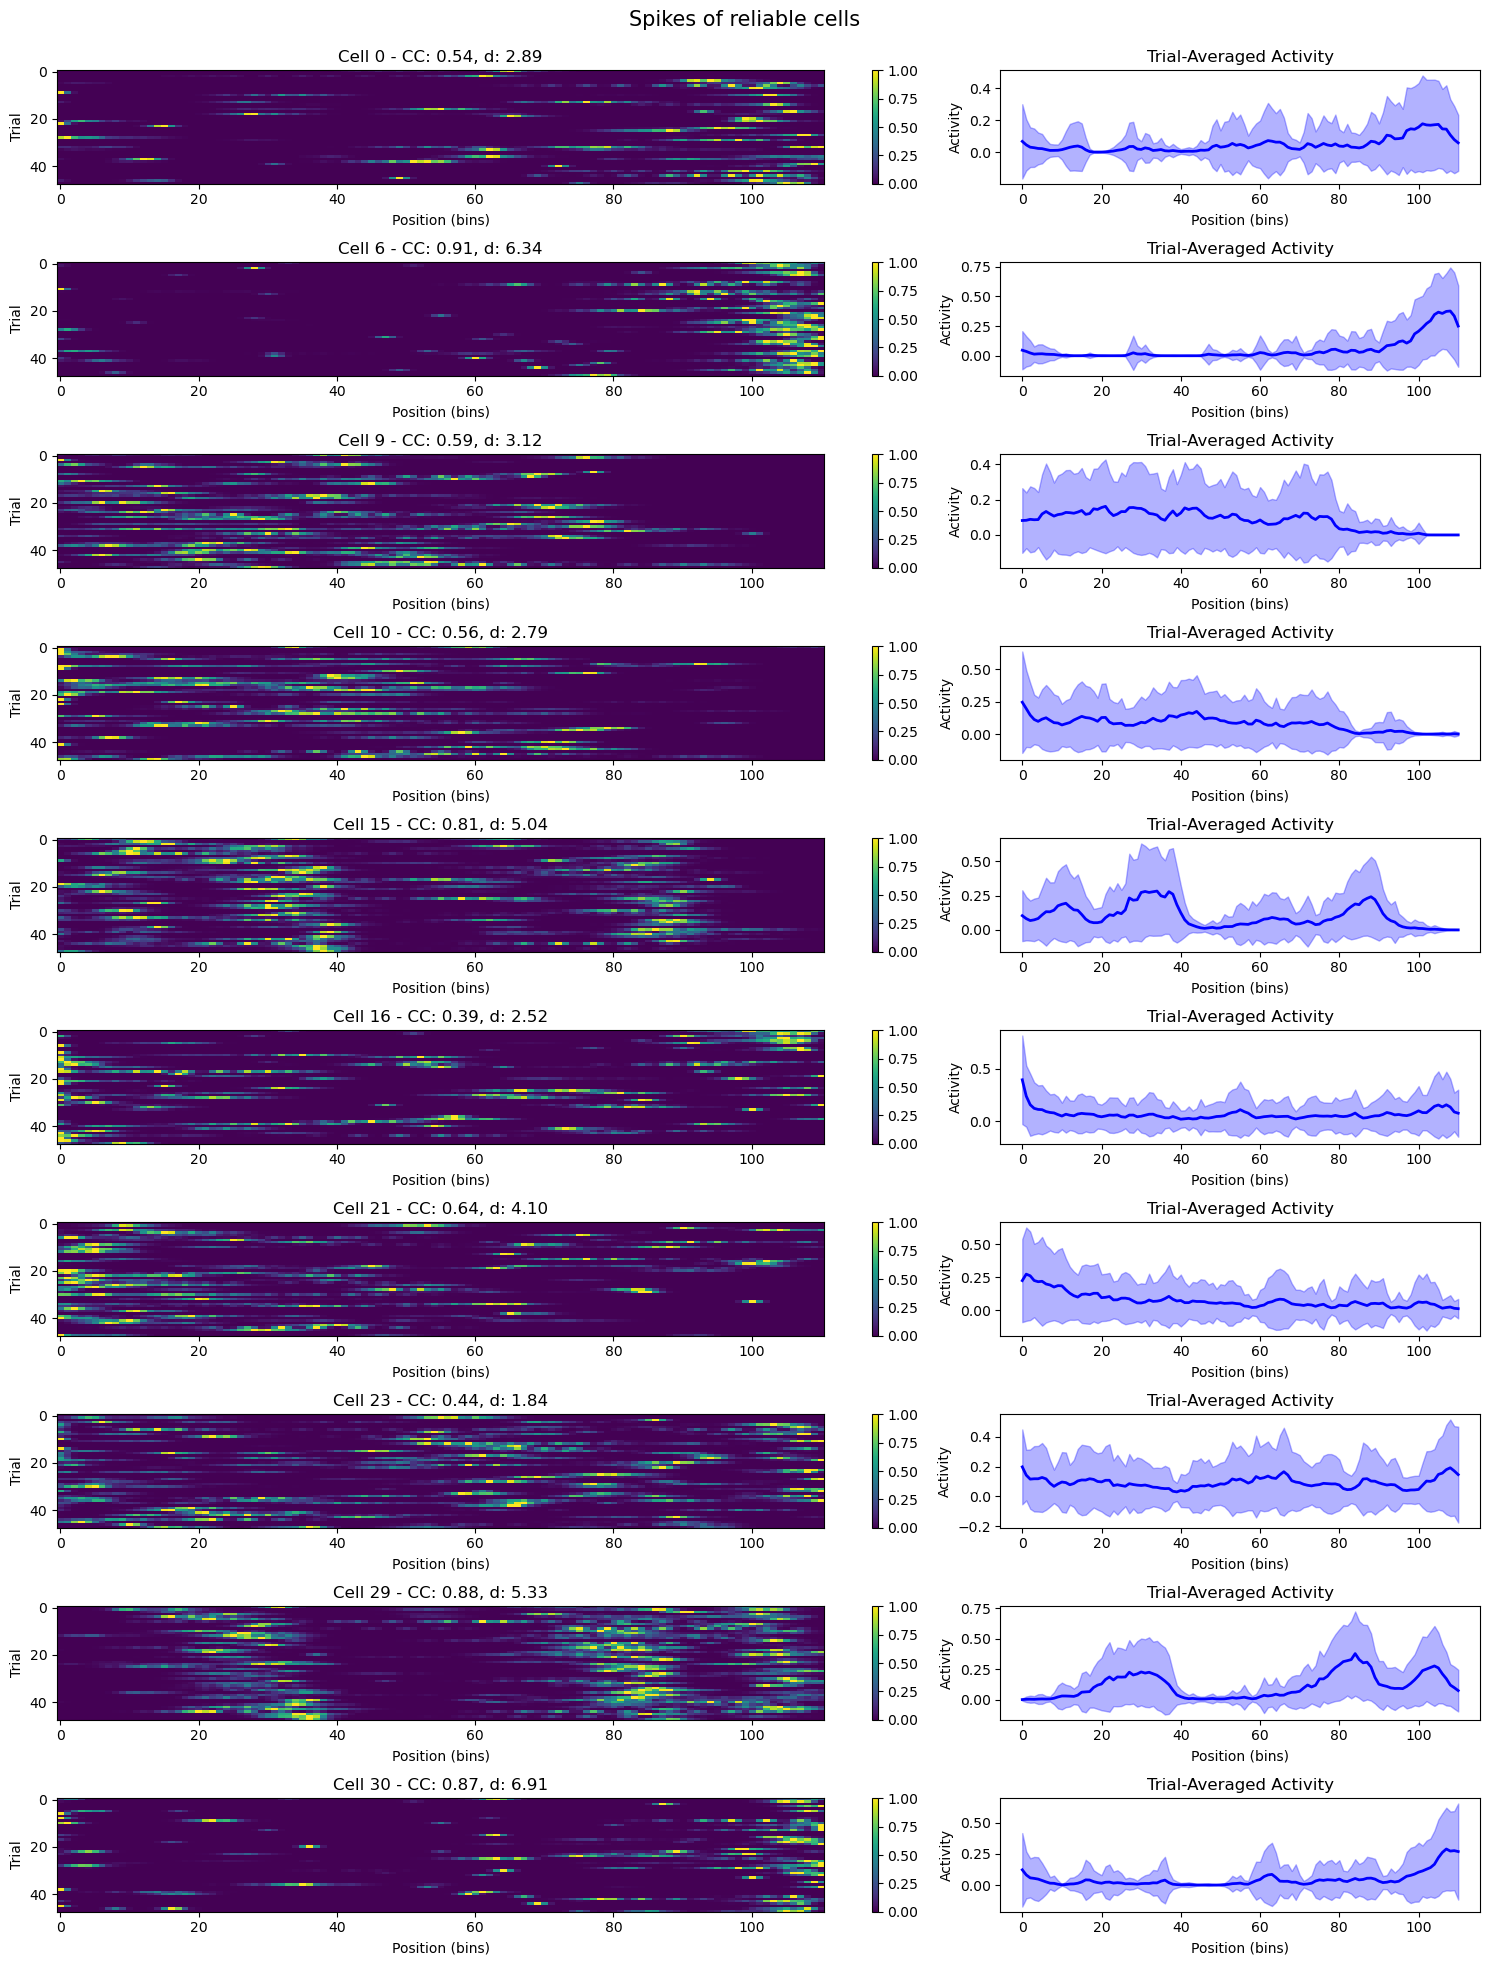

In [18]:
# # Option 1.1 Plot the average activity oin a grid layout
# reliable_avg = {}

# for i in np.where(reliable_cells)[0]:
#     reliable_avg[i] = np.mean(spatial_activity[i, :, :], axis=0)

# # plot average activity of first 25 reliable cells in a 5 x 5 subplots
# fig, axs = plt.subplots(5, 5, figsize=(20, 20))
# reliable_indices = list(reliable_avg.keys())[:25]
# for idx, i in enumerate(reliable_indices):
#     ax = axs[idx // 5, idx % 5]
#     ax.plot(bin_centers, reliable_avg[i])
#     ax.set_title(f'Cell {i}')
#     ax.set_xlabel('Position')
#     ax.set_ylabel('Activity')

# # set a title over all plots
# fig.suptitle('Average spikes of example reliable cells', fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.98])  # Adjust the rect parameter to add space at the top
# plt.show()

# # Option 1.2: Plot heatmaps in a grid layout (eg. 20 cells in a 5×4 grid)
# fig1 = RT.plot_reliable_cells_grid(
#     normalized_spatial_activity,
#     reliable_cells,
#     max_cells=20,                # Show up to 20 reliable cells
#     avg_cc=avg_cc,               # Optional correlation coefficients
#     cohen_d=cohens_d,            # Optional Cohen's D values
#     normalize=False,              # Apply normalization
#     n_rows=5,                    # 5 rows
#     n_cols=4                     # 4 columns
# )
# plt.suptitle('Spikes of reliable cells', fontsize=15)
# plt.tight_layout(rect=[0, 0, 1, 0.985])  # Adjust the rect parameter to add space at the top

# plt.show()

# Option 2: Plot with both heatmap and trial-averaged activity
fig2 = RT.plot_reliable_cells_side_by_side(
    normalized_spatial_activity,
    reliable_cells,
    max_cells=10,                # Show up to 10 reliable cells
    avg_cc=avg_cc,               # Optional correlation coefficients
    cohen_d=cohens_d,            # Optional Cohen's D values
    normalize=False               # Apply normalization
)
plt.suptitle('Spikes of reliable cells', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.985])  # Adjust the rect parameter to add space at the top
plt.show()

# # Option 3: Plot waterfall plots
# RT.plot_reliable_cells_waterfall(normalized_spatial_activity, reliable_cells, max_cells=np.sum(reliable_cells))
# plt.show()

In [ ]:
# Get overall statistics on trial differences
fig, stats = debug_trial_differences(
    normalized_activity, 
    reliable_cells, 
    exclude_first_n_bins=10
)
plt.savefig('trial_difference_diagnostics.png', dpi=300)
plt.show()

# Examine specific example cells
fig = examine_example_cells(
    normalized_activity, 
    reliable_cells, 
    exclude_first_n_bins=10,
    n_examples=20
)
plt.savefig('cell_examples.png', dpi=300)
plt.show()

**6. Plotting activity of all responsive cells (cross validation – split trials in half)**

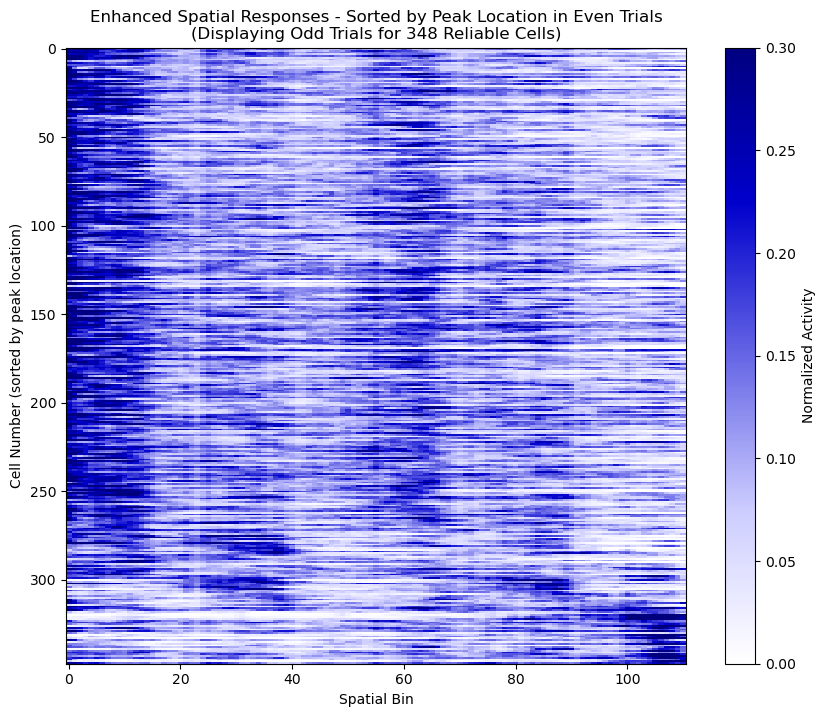

In [14]:
from helper import ResponseVisualization as RV
# fig1, sorted_indices = RV.create_response_plot(spatial_activity, reliable_cells)  # Optional: manually set contrast limits for stronger effect

fig1, sorted_indices = RV.create_response_plot(normalized_spatial_activity, reliable_cells, clim=(0, 0.3))  # Optional: manually set contrast limits for stronger effect
# draw a vertical line on a plot

# # For waterfall visualization (alternative approach):
# fig2 = RV.create_waterfall_plot(
#     normalized_spatial_activity,
#     reliable_cells
# )

plt.show()

**7. Population vector cross-correlation**